In [1]:
# Import necessary libraries

import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations
import pickle # For serializing and deserializing Python objects
from sklearn.metrics import roc_auc_score
import plotly.graph_objects as go

import sys
sys.path.append("/home/suraj/Repositories/TumorImagingBench/notebooks/modelling")

from modelling_utils import (
    train_knn_classifier, evaluate_model,
    train_linear_probing_classifier,
    train_few_shot_classifier,
    build_knn_ensemble_classifier, predict_with_ensemble,
    train_stacking_ensemble_classifier, predict_with_stacking_ensemble,
    plot_model_comparison, extract_model_features, 
    compute_knn_indices, compute_overlap_matrix, plot_overlap_matrix, 
    split_shuffle_data, apply_r_style
)

from pathlib import Path

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATASET_SLUG = 'colorectal_liver_metastases'
FIG_SIZE = 900


In [2]:
# Load features from a pickle file
feature_dict_path = "../../data/features/colorectal_liver_metastases.pkl" # Path to the pickle file containing features
with open(feature_dict_path, 'rb') as file: # Open the file in read binary mode
    data = pickle.load(file) # Load the data from the pickle file



{'train': [{'feature': array([[0.86516464, 0.8383121 , 0.8400758 , 0.88799316, 0.83035725,
           0.92540735, 0.9021751 , 0.8174803 , 0.8124806 , 0.8418973 ,
           0.9312484 , 0.8754188 , 0.73314244, 0.7844932 , 0.8630006 ,
           0.9724779 , 0.8565158 , 0.94035596, 0.6791718 , 0.7745483 ,
           0.8357411 , 0.60621333, 0.85867864, 0.83478236, 0.9222758 ,
           0.8444145 , 0.8200926 , 0.7556866 , 0.8572525 , 0.8567718 ,
           0.811267  , 0.9461153 , 0.72830474, 0.82082444, 0.79653996,
           0.8161254 , 0.90190125, 0.9200657 , 0.8765373 , 0.76942164,
           0.7845925 , 0.75867903, 0.73634577, 0.72252554, 0.7625191 ,
           1.0032011 , 0.76954806, 0.8019217 , 0.7296924 , 0.9513836 ,
           0.82485753, 0.85799927, 0.84064835, 0.7601138 , 0.872408  ,
           0.8662499 , 0.8914323 , 0.80342275, 0.6839943 , 0.95822346,
           0.9011027 , 0.7563481 , 0.9172219 , 0.9226977 , 0.8071377 ,
           0.7734752 , 0.87054443, 0.8476498 , 0.90782577

In [3]:
# Derive binary survival labels (~2-year) and attach to rows
for model_name, values in data.items():
    for dataset, entries in values.items():
        vital_months = [v["row"]["overall_survival_months"] for v in entries]
        vital_status = [v["row"]["vital_status"] for v in entries]
        survival = []

        for months, censor in zip(vital_months, vital_status):
            if months >= 24:
                survival.append(1)
            elif censor != 0 and months < 24:
                survival.append(0)
            else:
                survival.append(np.nan)

        for idx, entry in enumerate(entries):
            entry["row"]["survival"] = survival[idx]


In [4]:
# Store test accuracies for each model
test_accuracies_dict = {}

label_candidates = ["Malignant_lbl", "malignancy", "survival", "label", "target", "status"]

for model_name, values in data.items():
    print(f"Model: {model_name}")
    splits = [s for s in ["train", "val", "test"] if s in values and values[s]]
    if not splits:
        print("  Skipping: no splits found")
        continue

    sample_row = values[splits[0]][0]["row"]
    label_key = next((k for k in label_candidates if k in sample_row), list(sample_row.keys())[0])

    labels = []
    features = []
    for split in splits:
        labels.extend([v["row"][label_key] for v in values[split]])
        features.append(np.vstack([v["feature"] for v in values[split]]))

    labels_arr = np.array(labels)
    if labels_arr.dtype.kind in {"f", "c"}:
        mask = ~np.isnan(labels_arr)
    else:
        mask = np.ones_like(labels_arr, dtype=bool)

    all_items = np.vstack(features)[mask]
    all_labels = labels_arr[mask].tolist()

    n_splits = 10
    split_scores = []

    for split_idx in range(n_splits):
        train_items_s, train_labels_s, val_items_s, val_labels_s, test_items_s, test_labels_s = split_shuffle_data(
            all_items, all_labels, train_ratio=0.5, val_ratio=0.2, random_seed=10+split_idx, stratify=True
        )

        best_model, study = train_knn_classifier(train_items_s, train_labels_s, val_items_s, val_labels_s)
        split_score = evaluate_model(best_model, test_items_s, test_labels_s)
        split_scores.append(split_score)

    avg_score = np.mean(split_scores)
    std_error = np.std(split_scores, ddof=1) / np.sqrt(n_splits)
    margin = 1.96 * std_error
    ci_lower = avg_score - margin
    ci_upper = avg_score + margin

    test_accuracies_dict[model_name] = {"mean": avg_score, "ci95": (ci_lower, ci_upper)}
    print(f"  AUC: {avg_score:.4f} ± {margin:.4f}")

print("\n✓ KNN probing complete")


[I 2025-12-08 19:04:54,354] A new study created in memory with name: no-name-1f49fad9-cae9-4b39-b007-b981df380ffc


[I 2025-12-08 19:04:54,359] Trial 0 finished with value: 0.3821428571428571 and parameters: {'k': 29}. Best is trial 0 with value: 0.3821428571428571.


[I 2025-12-08 19:04:54,363] Trial 1 finished with value: 0.4821428571428571 and parameters: {'k': 12}. Best is trial 1 with value: 0.4821428571428571.


[I 2025-12-08 19:04:54,367] Trial 2 finished with value: 0.4821428571428571 and parameters: {'k': 11}. Best is trial 1 with value: 0.4821428571428571.


[I 2025-12-08 19:04:54,371] Trial 3 finished with value: 0.39999999999999997 and parameters: {'k': 42}. Best is trial 1 with value: 0.4821428571428571.


...

[I 2025-12-08 19:05:41,364] Trial 46 finished with value: 0.5678571428571428 and parameters: {'k': 4}. Best is trial 34 with value: 0.6107142857142858.


[I 2025-12-08 19:05:41,377] Trial 47 finished with value: 0.625 and parameters: {'k': 1}. Best is trial 47 with value: 0.625.


[I 2025-12-08 19:05:41,391] Trial 48 finished with value: 0.41428571428571426 and parameters: {'k': 48}. Best is trial 47 with value: 0.625.


[I 2025-12-08 19:05:41,404] Trial 49 finished with value: 0.37857142857142856 and parameters: {'k': 45}. Best is trial 47 with value: 0.625.


  AUC: 0.4744 ± 0.0459

✓ KNN probing complete


In [5]:
# Plot test accuracies
fig = plot_model_comparison(test_accuracies_dict, font_size=32, height=FIG_SIZE, width=1400, marker_color="#FCA308")
fig.write_image(PLOTS_DIR / f"colorectal_liver_metastases_auc.png")

fig.show()


In [6]:
# Intermediate save removed to prevent syntax errors


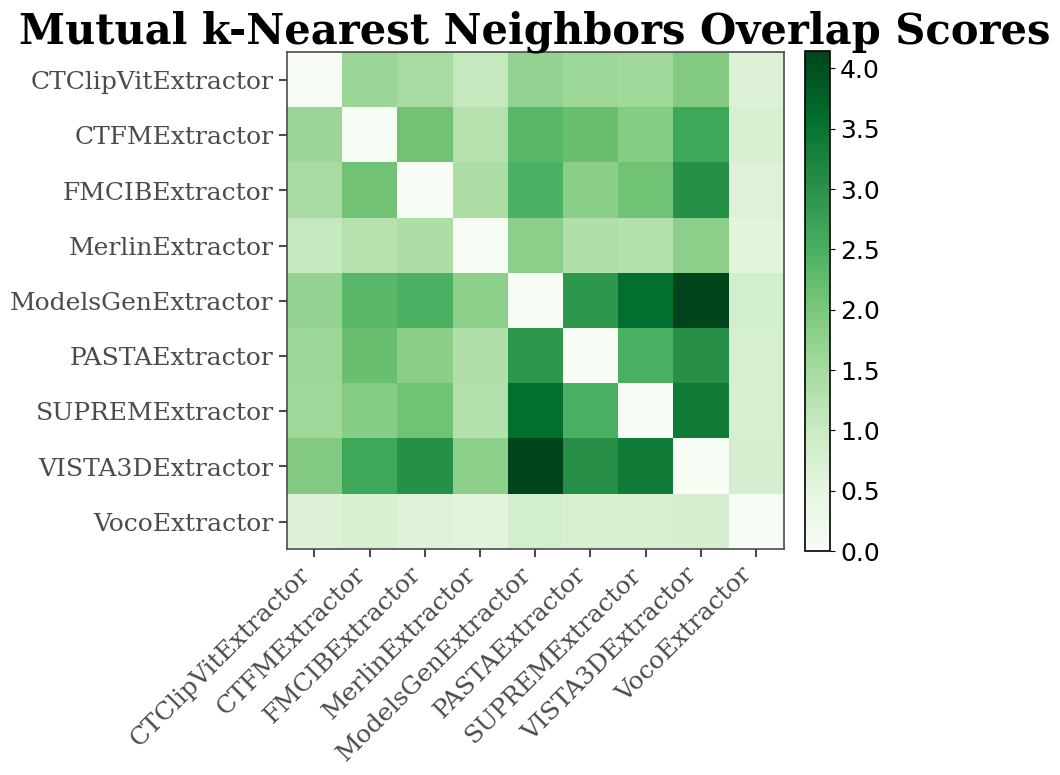

In [7]:
import matplotlib.pyplot as plt

model_features = extract_model_features(data)
model_neighbors = compute_knn_indices(model_features, num_neighbors=10, metric="cosine")
overlap_matrix, model_list = compute_overlap_matrix(model_neighbors)
fig = plot_overlap_matrix(overlap_matrix, model_list, font_size=30, tickangle=45, width=FIG_SIZE, height=FIG_SIZE)
fig.savefig(PLOTS_DIR / f"{DATASET_SLUG}_knn_overlap.png")

plt.show(block=False)

plt.close(fig)

## Linear Probing Evaluation

Evaluate foundation model features using linear probing (logistic regression).
This complements KNN probing and is the standard transfer learning baseline.

In [8]:
# Linear Probing - Train logistic regression on frozen features
linear_probing_results = {}

label_candidates = ["Malignancy", "Malignant_lbl", "malignancy", "survival", "label", "target", "status"]

for model_name, values in data.items():
    print(f"Linear Probing - {model_name}...")
    splits = [s for s in ["train", "val", "test"] if s in values and values[s]]
    if not splits:
        print("  Skipping: no splits found")
        continue

    sample_row = values[splits[0]][0]["row"]
    label_key = next((k for k in label_candidates if k in sample_row), list(sample_row.keys())[0])

    labels = []
    features = []
    for split in splits:
        labels.extend([v["row"][label_key] for v in values[split]])
        features.append(np.vstack([v["feature"] for v in values[split]]))

    labels_arr = np.array(labels)
    if labels_arr.dtype.kind in {"f", "c"}:
        mask = ~np.isnan(labels_arr)
    else:
        mask = np.ones_like(labels_arr, dtype=bool)

    all_items = np.vstack(features)[mask]
    all_labels = labels_arr[mask].tolist()

    n_splits = 10
    linear_split_scores = []

    for split in range(n_splits):
        train_items_s, train_labels_s, val_items_s, val_labels_s, test_items_s, test_labels_s = split_shuffle_data(
            all_items, all_labels, train_ratio=0.5, val_ratio=0.2, random_seed=10+split, stratify=True
        )

        linear_model, _ = train_linear_probing_classifier(train_items_s, train_labels_s, val_items_s, val_labels_s)
        linear_score = evaluate_model(linear_model, test_items_s, test_labels_s)
        linear_split_scores.append(linear_score)

    avg_score = np.mean(linear_split_scores)
    std_error = np.std(linear_split_scores, ddof=1) / np.sqrt(n_splits)
    margin = 1.96 * std_error
    ci_lower = avg_score - margin
    ci_upper = avg_score + margin

    linear_probing_results[model_name] = {"mean": avg_score, "ci95": (ci_lower, ci_upper)}
    print(f"  Linear Probing AUC: {avg_score:.4f} ± {margin:.4f}")

print("\n✓ Linear probing evaluation complete")


Linear Probing - CTClipVitExtractor...
  Linear Probing AUC: 0.4896 ± 0.0580
Linear Probing - CTFMExtractor...


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problem

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problem

  Linear Probing AUC: 0.4841 ± 0.0917
Linear Probing - FMCIBExtractor...


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



...

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problem

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



  Linear Probing AUC: 0.5396 ± 0.0827

✓ Linear probing evaluation complete


In [9]:
linear_probing_results

{'CTClipVitExtractor': {'mean': 0.48962962962962964,
  'ci95': (0.431587827897072, 0.5476714313621873)},
 'CTFMExtractor': {'mean': 0.484074074074074,
  'ci95': (0.39236543209876534, 0.5757827160493826)},
 'FMCIBExtractor': {'mean': 0.5274074074074073,
  'ci95': (0.43384584648594415, 0.6209689683288705)},
 'MerlinExtractor': {'mean': 0.4514814814814815,
  'ci95': (0.3813299223412209, 0.5216330406217421)},
 'ModelsGenExtractor': {'mean': 0.5207407407407407,
  'ci95': (0.4738424549947379, 0.5676390264867436)},
 'PASTAExtractor': {'mean': 0.4537037037037037,
  'ci95': (0.3810607170803333, 0.5263466903270742)},
 'SUPREMExtractor': {'mean': 0.4922222222222222,
  'ci95': (0.4111012856731814, 0.5733431587712631)},
 'VISTA3DExtractor': {'mean': 0.4833333333333333,
  'ci95': (0.4215063927349786, 0.545160273931688)},
 'VocoExtractor': {'mean': 0.5396296296296297,
  'ci95': (0.45692467795102865, 0.6223345813082307)}}

## Few-Shot Learning Evaluation

Evaluate foundation model generalization with limited training data (1-shot, 5-shot, 10-shot).
This assesses how well models work in clinical settings with limited labels.

In [10]:
# Few-Shot Learning - Evaluate with limited training samples
shot_configs = [1, 5, 10]
few_shot_results = {shots: {} for shots in shot_configs}

label_candidates = ["Malignant_lbl", "malignancy", "survival", "label", "target", "status"]

for model_name, values in data.items():
    print(f"Few-Shot Learning - {model_name}...")
    splits = [s for s in ["train", "val", "test"] if s in values and values[s]]
    if not splits:
        print("  Skipping: no splits found")
        continue

    sample_row = values[splits[0]][0]["row"]
    label_key = next((k for k in label_candidates if k in sample_row), list(sample_row.keys())[0])

    labels = []
    features = []
    for split in splits:
        labels.extend([v["row"][label_key] for v in values[split]])
        features.append(np.vstack([v["feature"] for v in values[split]]))

    labels_arr = np.array(labels)
    if labels_arr.dtype.kind in {"f", "c"}:
        mask = ~np.isnan(labels_arr)
    else:
        mask = np.ones_like(labels_arr, dtype=bool)

    all_items = np.vstack(features)[mask]
    all_labels = labels_arr[mask].tolist()

    for shots in shot_configs:
        n_splits = 10
        shot_scores = []

        for split in range(n_splits):
            train_items_s, train_labels_s, val_items_s, val_labels_s, test_items_s, test_labels_s = split_shuffle_data(
                all_items, all_labels, train_ratio=0.5, val_ratio=0.2, random_seed=10+split, stratify=True
            )

            np.random.seed(split)
            few_shot_model, _, _ = train_few_shot_classifier(
                train_items_s, train_labels_s,
                val_items_s, val_labels_s,
                shots=shots
            )

            test_score = evaluate_model(few_shot_model, test_items_s, test_labels_s)
            shot_scores.append(test_score)

        mean_score = np.mean(shot_scores)
        std_error = np.std(shot_scores, ddof=1) / np.sqrt(n_splits)
        margin = 1.96 * std_error

        few_shot_results[shots][model_name] = {"mean": mean_score, "ci95": (mean_score - margin, mean_score + margin)}

        if shots == 1:
            print(f"  {shots}-shot AUC: {mean_score:.4f} ± {margin:.4f} ... 10-shot: ", end="")
        elif shots == 10:
            print(f"{few_shot_results[shots][model_name]['mean']:.4f}")

print("\n✓ Few-shot learning evaluation complete")


[I 2025-12-08 19:06:03,254] A new study created in memory with name: no-name-6dbf963a-86b5-48d7-b4cd-8a79201a1571


[I 2025-12-08 19:06:03,258] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5.


[I 2025-12-08 19:06:03,262] Trial 1 finished with value: 0.3392857142857143 and parameters: {'k': 1}. Best is trial 0 with value: 0.5.


[I 2025-12-08 19:06:03,271] A new study created in memory with name: no-name-d727830e-4257-4bf8-8730-f01744c8e67f


[I 2025-12-08 19:06:03,275] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5.


...

[I 2025-12-08 19:06:19,043] Trial 15 finished with value: 0.39285714285714285 and parameters: {'k': 4}. Best is trial 5 with value: 0.7714285714285714.


[I 2025-12-08 19:06:19,047] Trial 16 finished with value: 0.55 and parameters: {'k': 1}. Best is trial 5 with value: 0.7714285714285714.


[I 2025-12-08 19:06:19,051] Trial 17 finished with value: 0.7714285714285714 and parameters: {'k': 16}. Best is trial 5 with value: 0.7714285714285714.


[I 2025-12-08 19:06:19,055] Trial 18 finished with value: 0.3607142857142857 and parameters: {'k': 13}. Best is trial 5 with value: 0.7714285714285714.


0.5167

✓ Few-shot learning evaluation complete


## Few-Shot Learning Curves

Visualize how model performance scales with increasing training samples.

In [11]:
# Plot few-shot learning curves

model_names = list(next(iter(few_shot_results.values())).keys())
fig = go.Figure()

for model_name in model_names:
    shot_values = []
    means = []
    cis = []

    for shots in shot_configs:
        shot_values.append(shots)
        result = few_shot_results.get(shots, {}).get(model_name, {})
        if "mean" not in result or "ci95" not in result:
            continue
        means.append(result["mean"])
        lower, upper = result["ci95"]
        cis.append(upper - result["mean"])

    fig.add_trace(go.Scatter(
        x=shot_values,
        y=means,
        mode='lines+markers',
        name=model_name,
        error_y=dict(type='data', array=cis, visible=True)
    ))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Few-Shot Learning Curves',
    xaxis_title='Number of shots',
    yaxis_title='Test AUC',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white'
)
fig.update_yaxes(range=[0, 1.0])
fig.write_image(PLOTS_DIR / f"colorectal_liver_metastases_few_shot.png")

fig.show()


## Comparison: KNN vs Linear Probing vs Few-Shot

In [12]:
# Create comparison visualization
model_names = list(linear_probing_results.keys())

knn_means = [test_accuracies_dict[m]['mean'] for m in model_names]
linear_means = [linear_probing_results[m]['mean'] for m in model_names]
few_shot_10_means = [few_shot_results[10][m]['mean'] for m in model_names]

knn_errors = [test_accuracies_dict[m]['ci95'][1] - test_accuracies_dict[m]['mean'] for m in model_names]
linear_errors = [linear_probing_results[m]['ci95'][1] - linear_probing_results[m]['mean'] for m in model_names]
few_shot_errors = [few_shot_results[10][m]['ci95'][1] - few_shot_results[10][m]['mean'] for m in model_names]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=model_names,
    y=knn_means,
    error_y=dict(type='data', array=knn_errors),
    name='KNN Probing',
    marker_color='#4ECDC4'
))

fig.add_trace(go.Bar(
    x=model_names,
    y=linear_means,
    error_y=dict(type='data', array=linear_errors),
    name='Linear Probing',
    marker_color='#FF6B6B'
))

fig.add_trace(go.Bar(
    x=model_names,
    y=few_shot_10_means,
    error_y=dict(type='data', array=few_shot_errors),
    name='10-Shot Learning',
    marker_color='#95E1D3'
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Evaluation Protocol Comparison',
    xaxis_title='Model',
    yaxis_title='Test AUC',
    barmode='group',
    height=FIG_SIZE,
    width=1400,
    template='simple_white',
    xaxis_tickangle=45
)
fig.update_yaxes(range=[0, 1.0])

fig.write_image(PLOTS_DIR / f"colorectal_liver_metastases_evaluation_protocols.png")

fig.show()

print(f"Correlation KNN vs Linear Probing: {np.corrcoef(knn_means, linear_means)[0, 1]:.4f}")
print(f"Correlation KNN vs 10-Shot: {np.corrcoef(knn_means, few_shot_10_means)[0, 1]:.4f}")
print("Interpretation:")
print("  High KNN-Linear correlation (>0.8): Consistent feature quality assessment")
print("  10-Shot vs KNN: Difference shows data-efficiency gains with simple learning")


Correlation KNN vs Linear Probing: 0.6719
Correlation KNN vs 10-Shot: 0.6070
Interpretation:
  High KNN-Linear correlation (>0.8): Consistent feature quality assessment
  10-Shot vs KNN: Difference shows data-efficiency gains with simple learning


## Alignment-Based Ensemble Method

Combine all models using mutual k-NN overlap alignment as weights.
Models with high alignment with others are weighted more heavily.


In [13]:
# Build alignment-based ensemble
print("Building alignment-based ensemble...\n")

# Extract all features for ensemble
ensemble_features_dict = {}
for model_name, values in data.items():
    features_list = []
    for split in ['train']:
        if split in values and values[split]:
            split_features = np.vstack([v['feature'] for v in values[split]])
            features_list.append(split_features)
    ensemble_features_dict[model_name] = np.vstack(features_list) if features_list else np.array([])

# Compute alignment (already computed earlier, but re-using for clarity)
all_labels_ensemble = []
label_source_idx = []
first_model = list(data.keys())[0]
for split in ['train']:
    for i, v in enumerate(data[first_model][split]):
        all_labels_ensemble.append(v['row'][label_key])
        label_source_idx.append(i)
all_labels_ensemble = np.array(all_labels_ensemble)

# Filter out samples with nan labels
valid_mask = ~pd.isnull(all_labels_ensemble)
all_labels_ensemble = all_labels_ensemble[valid_mask]
label_source_idx = np.array(label_source_idx)[valid_mask]

# All features must be filtered accordingly for index matching
for model_name in model_list:
    ensemble_features_dict[model_name] = ensemble_features_dict[model_name][valid_mask]


# Evaluate ensemble across multiple splits
n_splits = 10
ensemble_scores = []
individual_ensemble_scores = {m: [] for m in model_list}

for split_idx in range(n_splits):
    # Split data
    (train_idx, train_labels_s, val_idx, val_labels_s, 
     test_idx, test_labels_s) = split_shuffle_data(
        np.arange(len(all_labels_ensemble)), all_labels_ensemble,
        train_ratio=0.5, val_ratio=0.2, random_seed=10+split_idx, stratify=True
    )
    
    # Get features for each split
    train_features_dict = {m: ensemble_features_dict[m][train_idx] for m in model_list}
    val_features_dict = {m: ensemble_features_dict[m][val_idx] for m in model_list}
    test_features_dict = {m: ensemble_features_dict[m][test_idx] for m in model_list}
    
    # Build ensemble
    ensemble_model, ensemble_val = build_knn_ensemble_classifier(
        train_features_dict, train_labels_s,
        val_features_dict, val_labels_s,
        overlap_matrix.copy(), model_list, k=10
    )
    
    # Evaluate ensemble on test
    ensemble_test_preds = predict_with_ensemble(ensemble_model, test_features_dict, model_list)
    
    if ensemble_test_preds.shape[1] == 2:
        ensemble_auc = roc_auc_score(test_labels_s, ensemble_test_preds[:, 1])
    else:
        ensemble_auc = roc_auc_score(test_labels_s, ensemble_test_preds, multi_class='ovr')
    
    ensemble_scores.append(ensemble_auc)
    
    # Evaluate individual models
    from sklearn.neighbors import KNeighborsClassifier
    for model_name in model_list:
        knn = KNeighborsClassifier(n_neighbors=10, metric='cosine')
        knn.fit(train_features_dict[model_name], train_labels_s)
        test_preds = knn.predict_proba(test_features_dict[model_name])
        
        if test_preds.shape[1] == 2:
            model_auc = roc_auc_score(test_labels_s, test_preds[:, 1])
        else:
            model_auc = roc_auc_score(test_labels_s, test_preds, multi_class='ovr')
        
        individual_ensemble_scores[model_name].append(model_auc)
    
    if (split_idx + 1) % 5 == 0:
        print(f"  Completed {split_idx + 1}/{n_splits} splits")

# Compute ensemble statistics
ensemble_mean = np.mean(ensemble_scores)
ensemble_std = np.std(ensemble_scores, ddof=1) / np.sqrt(n_splits)
ensemble_ci = 1.96 * ensemble_std

print(f"\n✓ Ensemble evaluation complete")
print(f"\nEnsemble Performance:")
print(f"  Test AUC: {ensemble_mean:.4f} ± {ensemble_ci:.4f}")

# Compare to individual models
print(f"\nComparison to Individual Models:")
best_model_name = None
best_model_score = 0
for model_name in model_list:
    ind_mean = np.mean(individual_ensemble_scores[model_name])
    ind_std = np.std(individual_ensemble_scores[model_name], ddof=1) / np.sqrt(n_splits)
    ind_ci = 1.96 * ind_std
    improvement = ensemble_mean - ind_mean
    
    if ind_mean > best_model_score:
        best_model_score = ind_mean
        best_model_name = model_name
    
    print(f"  {model_name}: {ind_mean:.4f} ± {ind_ci:.4f}  (ensemble: {improvement:+.4f})")

print(f"\nBest Single Model: {best_model_name} ({best_model_score:.4f})")
print(f"Ensemble Advantage: {ensemble_mean - best_model_score:+.4f}")


Building alignment-based ensemble...



  Completed 5/10 splits


  Completed 10/10 splits

✓ Ensemble evaluation complete

Ensemble Performance:
  Test AUC: 0.4659 ± 0.0669

Comparison to Individual Models:
  CTClipVitExtractor: 0.4635 ± 0.0569  (ensemble: +0.0024)
  CTFMExtractor: 0.4478 ± 0.0932  (ensemble: +0.0181)
  FMCIBExtractor: 0.4967 ± 0.0399  (ensemble: -0.0307)
  MerlinExtractor: 0.4248 ± 0.0654  (ensemble: +0.0411)
  ModelsGenExtractor: 0.5572 ± 0.0571  (ensemble: -0.0913)
  PASTAExtractor: 0.3272 ± 0.0926  (ensemble: +0.1387)
  SUPREMExtractor: 0.4844 ± 0.0782  (ensemble: -0.0185)
  VISTA3DExtractor: 0.5996 ± 0.0643  (ensemble: -0.1337)
  VocoExtractor: 0.4822 ± 0.0754  (ensemble: -0.0163)

Best Single Model: VISTA3DExtractor (0.5996)
Ensemble Advantage: -0.1337


## Ensemble Model Weights

Visualize the alignment-based weights assigned to each model.


In [14]:
# Display ensemble weights from the first evaluation
# (Run one more iteration to get final ensemble model)
train_idx, train_labels_s, val_idx, val_labels_s, test_idx, test_labels_s = split_shuffle_data(
    np.arange(len(all_labels_ensemble)), all_labels_ensemble,
    train_ratio=0.5, val_ratio=0.2, random_seed=50, stratify=True
)

train_features_dict = {m: ensemble_features_dict[m][train_idx] for m in model_list}
val_features_dict = {m: ensemble_features_dict[m][val_idx] for m in model_list}

final_ensemble, _ = build_knn_ensemble_classifier(
    train_features_dict, train_labels_s,
    val_features_dict, val_labels_s,
    overlap_matrix.copy(), model_list, k=10
)

# Extract and visualize weights
weights = final_ensemble['weights']
models_for_plot = list(weights.keys())
weight_values = list(weights.values())

fig = go.Figure()
fig.add_trace(go.Bar(
    x=models_for_plot,
    y=weight_values,
    marker_color='#FCA308',
    text=[f'{w:.3f}' for w in weight_values],
    textposition='auto',
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Ensemble Model Weights (Based on k-NN Alignment)',
    xaxis_title='Model',
    yaxis_title='Weight',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45
)
fig.update_yaxes(range=[0, max(weight_values) * 1.15])

fig.write_image(PLOTS_DIR / f"{DATASET_SLUG}_alignment_weights.png")

fig.show()

print(f"\nWeight Statistics:")
print(f"  Max weight: {max(weight_values):.4f}")
print(f"  Min weight: {min(weight_values):.4f}")
print(f"  All weights sum to: {sum(weight_values):.4f}")
print(f"\nInterpretation:")
print(f"  Higher weight = better alignment with other models (consensus)")
print(f"  Lower weight = unique/diverse representation (adds complementary info)")



Weight Statistics:
  Max weight: 0.1547
  Min weight: 0.0480
  All weights sum to: 1.0000

Interpretation:
  Higher weight = better alignment with other models (consensus)
  Lower weight = unique/diverse representation (adds complementary info)


## Stacked Ensemble with Learned Weights

Train a logistic-regression meta-learner on top of per-model k-NN probabilities.

In [15]:
# Stacking ensemble with learned weights (meta-learned combination of models)
from sklearn.neighbors import KNeighborsClassifier

print("Evaluating stacking ensemble with learned weights...")

n_splits = 10
stacking_scores = []
stacking_val_scores = []
last_stacking_model = None
stacking_base_scores = {m: [] for m in model_list}

for split_idx in range(n_splits):
    (train_idx, train_labels_s, val_idx, val_labels_s,
     test_idx, test_labels_s) = split_shuffle_data(
        np.arange(len(all_labels_ensemble)), all_labels_ensemble,
        train_ratio=0.5, val_ratio=0.2, random_seed=110 + split_idx, stratify=True
    )

    train_features_dict = {m: ensemble_features_dict[m][train_idx] for m in model_list}
    val_features_dict = {m: ensemble_features_dict[m][val_idx] for m in model_list}
    test_features_dict = {m: ensemble_features_dict[m][test_idx] for m in model_list}

    stacking_model, val_auc = train_stacking_ensemble_classifier(
        train_features_dict, train_labels_s,
        val_features_dict, val_labels_s,
        k_candidates=(5, 10, 15, 25),
        meta_C_candidates=(0.25, 1.0, 4.0),
    )
    last_stacking_model = stacking_model
    stacking_val_scores.append(val_auc)

    test_pred = predict_with_stacking_ensemble(stacking_model, test_features_dict)
    if test_pred.shape[1] == 2:
        test_auc = roc_auc_score(test_labels_s, test_pred[:, 1])
    else:
        test_auc = roc_auc_score(test_labels_s, test_pred, multi_class='ovr')
    stacking_scores.append(test_auc)

    # Track single-model performance using the same k as the chosen base models
    k_for_base = stacking_model['k']
    for model_name in model_list:
        knn = KNeighborsClassifier(n_neighbors=k_for_base, metric="cosine")
        knn.fit(train_features_dict[model_name], train_labels_s)
        base_pred = knn.predict_proba(test_features_dict[model_name])
        if base_pred.shape[1] == 2:
            base_auc = roc_auc_score(test_labels_s, base_pred[:, 1])
        else:
            base_auc = roc_auc_score(test_labels_s, base_pred, multi_class='ovr')
        stacking_base_scores[model_name].append(base_auc)

    if (split_idx + 1) % 5 == 0:
        print(f"  Completed {split_idx + 1}/{n_splits} splits")

stacking_mean = np.mean(stacking_scores)
stacking_ci = 1.96 * np.std(stacking_scores, ddof=1) / np.sqrt(n_splits)
val_mean = np.mean(stacking_val_scores)

print(f"Stacking ensemble test AUC: {stacking_mean:.4f} ± {stacking_ci:.4f}")
print(f"Validation AUC (meta search average): {val_mean:.4f}")

best_single = None
best_single_score = -np.inf
for model_name, scores in stacking_base_scores.items():
    mean_score = np.mean(scores)
    if mean_score > best_single_score:
        best_single_score = mean_score
        best_single = model_name

print(f"Best single model (matched k): {best_single} — {best_single_score:.4f}")
print(f"Ensemble advantage over best single: {stacking_mean - best_single_score:+.4f}")


Evaluating stacking ensemble with learned weights...


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

...

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

  Completed 10/10 splits
Stacking ensemble test AUC: 0.4581 ± 0.0614
Validation AUC (meta search average): 0.9157
Best single model (matched k): VISTA3DExtractor — 0.5356
Ensemble advantage over best single: -0.0774


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

In [16]:
# Visualize meta-learner weights from the last stacking run
if last_stacking_model is None:
    raise RuntimeError("Run the stacking ensemble cell before visualizing weights.")

meta_model = last_stacking_model['meta_model']
model_list = last_stacking_model['model_list']
coef = meta_model.coef_

n_models = len(model_list)
cols_per_model = coef.shape[1] // n_models

weight_rows = []
for idx, name in enumerate(model_list):
    start = idx * cols_per_model
    end = start + cols_per_model
    block = coef[0, start:end]
    weight_rows.append({
        "model": name,
        "meta_weight": float(np.mean(block))
    })

weight_df = pd.DataFrame(weight_rows)
weight_df['normalized'] = np.exp(weight_df['meta_weight']) / np.exp(weight_df['meta_weight']).sum()
weight_df = weight_df.sort_values('normalized', ascending=False)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=weight_df['model'],
    y=weight_df['normalized'],
    marker_color='#4ECDC4',
    text=[f"{w:.3f}" for w in weight_df['normalized']],
    textposition='auto'
))
apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Stacking Ensemble Meta-weights (softmax-normalized coefficients)',
    xaxis_title='Model',
    yaxis_title='Normalized weight',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45,
)
fig.update_yaxes(range=[0, weight_df['normalized'].max() * 1.15])

fig.write_image(PLOTS_DIR / f"{DATASET_SLUG}_stacking_weights.png")

fig.show()

print("Raw meta coefficients (per-model mean):")
print(weight_df[['model', 'meta_weight']].to_string(index=False))


Raw meta coefficients (per-model mean):
             model  meta_weight
  VISTA3DExtractor     2.409021
   MerlinExtractor     1.901664
     CTFMExtractor     1.477861
    PASTAExtractor     1.104562
   SUPREMExtractor     0.544783
     VocoExtractor     0.295125
CTClipVitExtractor    -0.410348
    FMCIBExtractor    -2.345097
ModelsGenExtractor    -2.682078


In [17]:
# Compare ensembles against best single model
if 'ensemble_mean' not in globals() or 'stacking_mean' not in globals():
    raise RuntimeError("Run alignment and stacking sections first.")

best_single_name = best_model_name
best_single_mean = best_model_score
best_single_ci = 1.96 * np.std(individual_ensemble_scores[best_single_name], ddof=1) / np.sqrt(len(individual_ensemble_scores[best_single_name]))

labels = [f"Best single ({best_single_name})", "Alignment ensemble", "Stacking ensemble"]
means = [best_single_mean, ensemble_mean, stacking_mean]
errors = [best_single_ci, ensemble_ci, stacking_ci]
colors = ['#4ECDC4', '#FCA308', '#FF6B6B']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=labels,
    y=means,
    error_y=dict(type='data', array=errors),
    marker_color=colors,
    text=[f"{m:.3f}" for m in means],
    textposition='auto'
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Alignment vs Stacking vs Best Single',
    xaxis_title='Model',
    yaxis_title='Test AUC',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=20
)
fig.update_yaxes(range=[0, 1.0])
fig.write_image(PLOTS_DIR / f"{DATASET_SLUG}_ensemble_comparison.png")

fig.show()

print(f"Stacking uplift over best single: {stacking_mean - best_single_mean:+.4f}")
print(f"Stacking uplift over alignment ensemble: {stacking_mean - ensemble_mean:+.4f}")


Stacking uplift over best single: -0.1415
Stacking uplift over alignment ensemble: -0.0078


In [18]:
# Plot ensemble vs single-model performance
model_names_plot = list(individual_ensemble_scores.keys())
ind_means = [np.mean(individual_ensemble_scores[m]) for m in model_names_plot]
ind_errors = [1.96 * np.std(individual_ensemble_scores[m], ddof=1) / np.sqrt(len(individual_ensemble_scores[m])) for m in model_names_plot]

ensembles = [(ensemble_mean, ensemble_ci), (stacking_mean, stacking_ci)]

final_ensemble_mean, final_ensemble_ci = max(ensembles, key=lambda x: x[0])

bar_names = model_names_plot + ["Ensemble"]
bar_means = ind_means + [final_ensemble_mean]
bar_errors = ind_errors + [final_ensemble_ci]

colors = ['#4ECDC4'] * len(model_names_plot) + ['#FCA308']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=bar_names,
    y=bar_means,
    error_y=dict(type='data', array=bar_errors),
    marker_color=colors,
    text=[f"{m:.3f}" for m in bar_means],
    textposition='auto'
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Ensemble vs Individual Models',
    xaxis_title='Model',
    yaxis_title='Test AUC',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45
)
fig.update_yaxes(range=[0, 1.0])

fig.write_image(PLOTS_DIR / f"{DATASET_SLUG}_ensemble_vs_individual.png")

fig.show()

best_ind_mean = max(ind_means) if ind_means else float('nan')
print(f"Ensemble uplift over best single: {ensemble_mean - best_ind_mean:+.4f}")


Ensemble uplift over best single: -0.1337


In [19]:
# Intermediate save removed to prevent syntax errors


In [20]:
# Save all results to CSV
import pandas as pd
from pathlib import Path

def update_results_csv():
    results_map = {
        'KNN': test_accuracies_dict,
        'Linear': linear_probing_results,
        '10Shot': few_shot_results[10]
    }
    
    csv_path = Path('/home/suraj/Repositories/TumorImagingBench/overall_results.csv')
    if csv_path.exists():
        try:
            df = pd.read_csv(csv_path)
            if 'Models' in df.columns:
                df.set_index('Models', inplace=True)
            # Remove Unnamed columns
            df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
            # Drop old columns for this dataset to refresh
            cols_to_drop = [c for c in df.columns if c.startswith(f'{DATASET_SLUG}')]
            df.drop(columns=cols_to_drop, inplace=True)
        except Exception as e:
            print(f'Error reading CSV: {e}')
            df = pd.DataFrame()
    else:
        df = pd.DataFrame()

    # Process per-model results
    for strategy, results in results_map.items():
        for model, metrics in results.items():
            if model not in df.index:
                df.loc[model, :] = pd.NA
            
            prefix = f'{DATASET_SLUG}_{strategy}'
            df.loc[model, prefix] = metrics['mean']
            df.loc[model, f'{prefix}_CI_Lower'] = metrics['ci95'][0]
            df.loc[model, f'{prefix}_CI_Upper'] = metrics['ci95'][1]

    # Process Ensemble
    ens_mean, ens_ci = None, None
    if 'stacking_mean' in globals():
        ens_mean = stacking_mean
        ens_ci = stacking_ci
    elif 'ensemble_mean' in globals():
        ens_mean = ensemble_mean
        ens_ci = ensemble_ci

    if ens_mean is not None:
        ens_model = 'Ensemble'
        if ens_model not in df.index:
            df.loc[ens_model, :] = pd.NA
        
        # Save ensemble result. Use a specific strategy name or repurpose one?
        # Let's use 'Ensemble' as strategy suffix
        prefix = f'{DATASET_SLUG}_Ensemble'
        df.loc[ens_model, prefix] = ens_mean
        df.loc[ens_model, f'{prefix}_CI_Lower'] = ens_mean - ens_ci
        df.loc[ens_model, f'{prefix}_CI_Upper'] = ens_mean + ens_ci

    df.reset_index(names='Models', inplace=True)
    df.to_csv(csv_path, index=False)
    print('Results updated in overall_results.csv')

update_results_csv()


Results updated in overall_results.csv
